# Chest X-Ray Pneumonia Classification
Binary classification: Normal vs Pneumonia using ResNet18 transfer learning.

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

## 1. Download Kaggle Dataset

In [3]:
!pip install -q kaggle
import os, json

# Option A: Upload kaggle.json via file browser
# 1. Click the folder icon on the left sidebar
# 2. Click the upload icon and upload kaggle.json
# 3. Run this cell

if os.path.exists('/content/kaggle.json'):
    !mkdir -p ~/.kaggle
    !cp /content/kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content --unzip
else:
    # Option B: Paste your Kaggle username and key here
    KAGGLE_USERNAME = "proric"      # <-- replace
    KAGGLE_KEY = "KGAT_c8e10cef0e01554aa2ef594d82365aa1"                # <-- replace
    os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
    os.environ['KAGGLE_KEY'] = KAGGLE_KEY
    !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content --unzip

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:17<00:00, 138MB/s] 



## 2. Data Transforms & Loaders

In [4]:
DATA_DIR = '/content/chest_xray'
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_WORKERS = 2

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

image_datasets = {
    x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x])
    for x in ['train', 'val', 'test']
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=(x == 'train'), num_workers=NUM_WORKERS)
    for x in ['train', 'val', 'test']
}

class_names = image_datasets['train'].classes
print(f"Classes: {class_names}")
print(f"Train: {len(image_datasets['train'])}, Val: {len(image_datasets['val'])}, Test: {len(image_datasets['test'])}")

Classes: ['NORMAL', 'PNEUMONIA']
Train: 5216, Val: 16, Test: 624


## 3. Model: ResNet18 Transfer Learning

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 1)  # binary: single output + BCEWithLogitsLoss
model = model.to(device)

print(f"Last conv layer: {model.layer4[-1].conv2}")

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]


Last conv layer: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)


## 4. Training Setup

In [6]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
NUM_EPOCHS = 8

train_loss_history, val_loss_history = [], []
train_acc_history, val_acc_history = [], []

## 5. Train

In [7]:
def train_model(model, criterion, optimizer, num_epochs):
    best_val_acc = 0.0
    
    for epoch in range(num_epochs):
        # Train
        model.train()
        running_loss, running_corrects, total = 0.0, 0, 0
        
        for inputs, labels in dataloaders['train']:
            inputs, labels = inputs.to(device), labels.to(device).float()
            optimizer.zero_grad()
            outputs = model(inputs).squeeze(1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum((torch.sigmoid(outputs) > 0.5).float() == labels).item()
            total += labels.size(0)
        
        train_loss = running_loss / total
        train_acc = running_corrects / total
        
        # Validate
        model.eval()
        val_loss, val_corrects, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for inputs, labels in dataloaders['val']:
                inputs, labels = inputs.to(device), labels.to(device).float()
                outputs = model(inputs).squeeze(1)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum((torch.sigmoid(outputs) > 0.5).float() == labels).item()
                val_total += labels.size(0)
        
        val_loss = val_loss / val_total
        val_acc = val_corrects / val_total
        
        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        train_acc_history.append(train_acc)
        val_acc_history.append(val_acc)
        
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
    
    model.load_state_dict(torch.load('best_model.pth'))
    return model

model = train_model(model, criterion, optimizer, NUM_EPOCHS)

Epoch 1/8 | Train Loss: 0.1272 Acc: 0.9536 | Val Loss: 0.7756 Acc: 0.6250
Epoch 2/8 | Train Loss: 0.0646 Acc: 0.9778 | Val Loss: 0.0819 Acc: 1.0000
Epoch 3/8 | Train Loss: 0.0425 Acc: 0.9856 | Val Loss: 0.1174 Acc: 0.9375
Epoch 4/8 | Train Loss: 0.0426 Acc: 0.9849 | Val Loss: 0.2617 Acc: 0.8750
Epoch 5/8 | Train Loss: 0.0400 Acc: 0.9858 | Val Loss: 0.3442 Acc: 0.7500
Epoch 6/8 | Train Loss: 0.0356 Acc: 0.9872 | Val Loss: 0.1808 Acc: 0.8750
Epoch 7/8 | Train Loss: 0.0230 Acc: 0.9916 | Val Loss: 0.3092 Acc: 0.8750
Epoch 8/8 | Train Loss: 0.0325 Acc: 0.9885 | Val Loss: 0.0997 Acc: 1.0000


## 6. Loss & Accuracy Plots

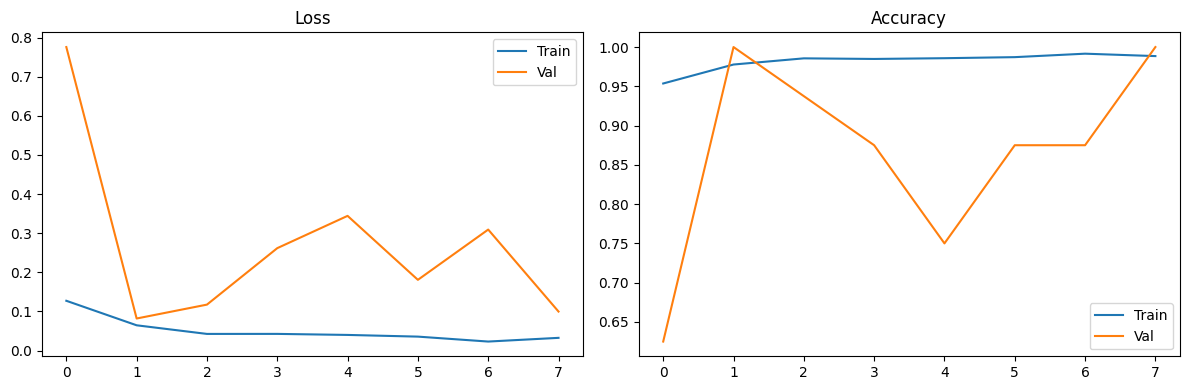

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_loss_history, label='Train'); ax1.plot(val_loss_history, label='Val')
ax1.set_title('Loss'); ax1.legend()
ax2.plot(train_acc_history, label='Train'); ax2.plot(val_acc_history, label='Val')
ax2.set_title('Accuracy'); ax2.legend()
plt.tight_layout(); plt.savefig('training_curves.png'); plt.show()

## 7. Test Evaluation

In [9]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        outputs = model(inputs).squeeze(1)
        preds = (torch.sigmoid(outputs) > 0.5).float().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Confusion Matrix:\n{cm}")

Accuracy:  0.9295
Precision: 0.9303
Recall:    0.9590
F1 Score:  0.9444
Confusion Matrix:
[[206  28]
 [ 16 374]]


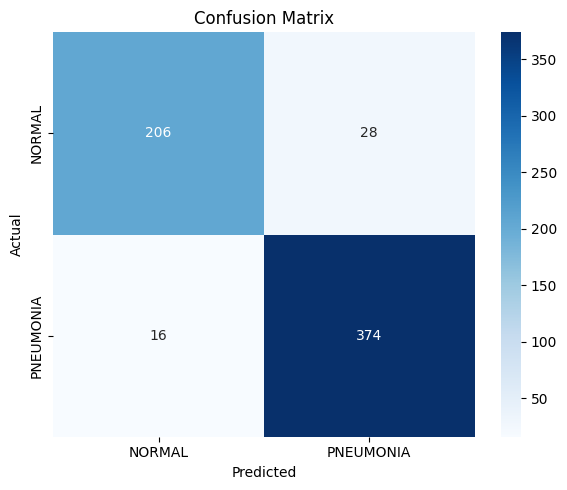

Confusion matrix saved as confusion_matrix.png


In [10]:
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix'); plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved as confusion_matrix.png")

## 8. Save Final Model & Print Last Conv Layer

In [11]:
torch.save(model.state_dict(), 'model.pth')
print("Model saved as model.pth")

# Print the last conv layer name (needed for Grad-CAM)
last_conv = None
for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        last_conv = name

print(f"\nLast convolutional layer: {last_conv}")

Model saved as model.pth

Last convolutional layer: layer4.1.conv2
